In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
plt.style.use('ggplot')

In [52]:
order = pd.read_csv('datathon_2026_round1/dataset/interim/csv_exports/orders_base.csv')

In [12]:
order_items = pd.read_csv('datathon_2026_round1/dataset/interim/csv_exports/order_items_base.csv')

C:\Users\hfake\AppData\Local\Temp\ipykernel_2368\1292588466.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv('datathon_2026_round1/dataset/interim/csv_exports/order_items_base.csv')


In [13]:
order.dtypes

order_id           int64
order_date        object
customer_id        int64
zip                int64
order_status      object
payment_method    object
device_type       object
order_source      object
dtype: object

In [14]:
order_items.dtypes

order_id             int64
product_id           int64
quantity             int64
discount_amount    float64
promo_id            object
promo_id_2          object
unit_price         float64
dtype: object

In [53]:
order['order_date'] = pd.to_datetime(order['order_date'])

In [17]:
order_items['order_id'].isnull().sum()

np.int64(0)

In [54]:
order = order.merge(
    order_items,
    left_on='order_id',
    right_on='order_id',
    how='left'
)

In [33]:
order

,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source,product_id,quantity,discount_amount,promo_id,promo_id_2,unit_price
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search,2400,7,0.0,NaN,NaN,1138.22
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search,609,7,0.0,NaN,NaN,10166.25
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct,396,3,0.0,NaN,NaN,11220.33
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral,635,5,0.0,NaN,NaN,10639.25
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign,1935,1,0.0,NaN,NaN,1597.84
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
714648,834372,2022-12-31,19490,33907,delivered,credit_card,mobile,email_campaign,690,8,0.0,NaN,NaN,4473.92
714649,834377,2022-12-31,73046,37091,delivered,credit_card,mobile,referral,1995,7,0.0,NaN,NaN,5250.79
714650,834387,2022-12-31,107723,80516,delivered,credit_card,mobile,email_campaign,2331,8,0.0,NaN,NaN,7389.06
714651,834392,2022-12-31,139431,93510,delivered,paypal,desktop,direct,1115,5,0.0,NaN,NaN,4767.33


In [55]:
order = (
    order
    .groupby('order_date')
    .agg(
        Total_Orders=('order_id', 'nunique'),
        Total_Order_Items=('order_id', 'count')
    )
    .reset_index()
    .rename(columns={'order_date': 'date'})
)

In [56]:
order

,date,Total_Orders,Total_Order_Items
0,2012-07-04,162,174
1,2012-07-05,97,103
2,2012-07-06,93,99
3,2012-07-07,73,75
4,2012-07-08,88,94
...,...,...,...
3828,2022-12-27,108,125
3829,2022-12-28,164,192
3830,2022-12-29,143,159
3831,2022-12-30,106,116


In [21]:
order['order_id'].value_counts()

order_id
348761    5
594591    5
136178    4
221569    4
530368    4
         ..
298938    1
298941    1
298942    1
298943    1
834397    1
Name: count, Length: 646945, dtype: int64

In [22]:
order['order_id'].duplicated().sum()

np.int64(67708)

In [23]:
order.query('order_id == 348761')

,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source,product_id,quantity,discount_amount,promo_id,promo_id_2,unit_price
305768,348761,2015-12-26,71190,35405,delivered,credit_card,tablet,paid_search,1113,3,926.39,PROMO-0014,NaN,1543.98
305769,348761,2015-12-26,71190,35405,delivered,credit_card,tablet,paid_search,2224,6,751.79,PROMO-0014,NaN,626.49
305770,348761,2015-12-26,71190,35405,delivered,credit_card,tablet,paid_search,2225,4,473.33,PROMO-0014,NaN,591.66
305771,348761,2015-12-26,71190,35405,delivered,credit_card,tablet,paid_search,2254,4,469.58,PROMO-0014,NaN,586.97
305772,348761,2015-12-26,71190,35405,delivered,credit_card,tablet,paid_search,2255,4,461.66,PROMO-0014,NaN,577.07


In [24]:
order['order_date'].value_counts()

order_date
2018-05-30    885
2018-05-31    835
2017-03-30    800
2014-04-29    782
2018-06-01    778
             ... 
2021-01-02     17
2021-03-02     15
2020-01-02     14
2013-03-02      9
2020-02-29      8
Name: count, Length: 3833, dtype: int64

In [57]:
sales = pd.read_csv('datathon_2026_round1/dataset/interim/csv_exports/sales_base.csv')

In [59]:
sales['date'] = pd.to_datetime(sales['date'])

In [60]:
sales_order = sales.merge(
    order,
    on='date',
    how='left'
)

In [61]:
sales_order

,date,revenue,cogs,Total_Orders,Total_Order_Items
0,2012-07-04,5123547.94,3982991.19,162,174
1,2012-07-05,2751773.45,2150580.23,97,103
2,2012-07-06,3054029.42,2517632.84,93,99
3,2012-07-07,2667930.94,2108246.62,73,75
4,2012-07-08,2360851.90,1808622.79,88,94
...,...,...,...,...,...
3828,2022-12-27,2100553.66,2184872.24,108,125
3829,2022-12-28,3448729.20,3513621.00,164,192
3830,2022-12-29,3083944.33,3170787.10,143,159
3831,2022-12-30,2884668.76,3022292.15,106,116


<Figure size 1600x600 with 0 Axes>

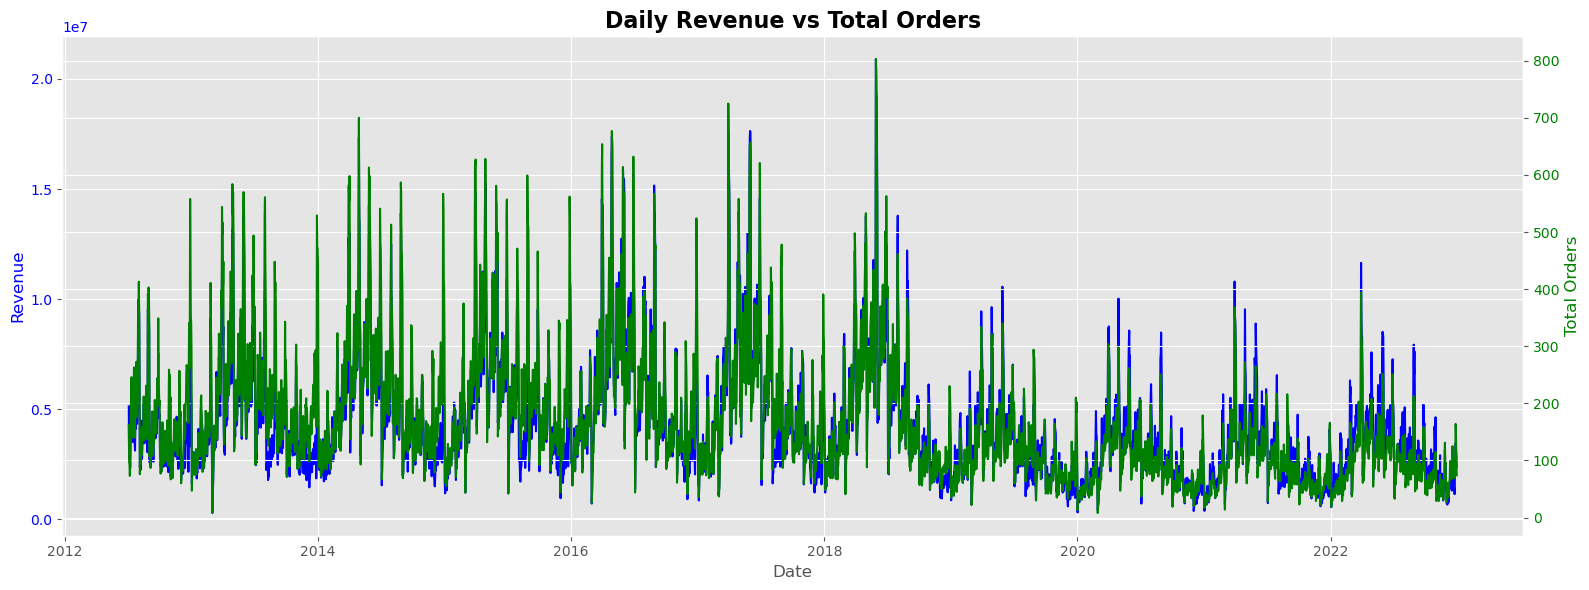

In [62]:
plt.figure(figsize=(16,6))

fig, ax1 = plt.subplots(figsize=(16,6))

ax1.plot(
    sales_order['date'],
    sales_order['revenue'],
    label='Revenue',
    color='blue'
)

ax1.set_xlabel('Date')
ax1.set_ylabel('Revenue', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()

ax2.plot(
    sales_order['date'],
    sales_order['Total_Orders'],
    label='Total Orders',
    color='green'
)

ax2.set_ylabel('Total Orders', color='green')
ax2.tick_params(axis='y', labelcolor='green')

plt.title(
    'Daily Revenue vs Total Orders',
    fontsize=16,
    fontweight='bold'
)

fig.tight_layout()
plt.savefig(
    'chart3_1.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [ ]:
sales_order['Revenue_30D'] = (
    sales_order['revenue']
    .rolling(window=30)
    .mean()
)

sales_order['Orders_30D'] = (
    sales_order['Total_Orders']
    .rolling(window=30)
    .mean()
)

fig, ax1 = plt.subplots(figsize=(16,6))

Revenue 30D
ax1.plot(
    sales_order['date'],
    sales_order['Revenue_30D'],
    label='Revenue 30D Trend',
    color='blue',
    linewidth=3
)

ax1.set_xlabel('Date')
ax1.set_ylabel('Revenue 30D', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()

ax2.plot(
    df['Date'],
    df['Orders_30D'],
    label='Orders 30D Trend',
    color='green',
    linewidth=3
)

ax2.set_ylabel('Total Orders 30D', color='green')
ax2.tick_params(axis='y', labelcolor='green')

plt.title(
    'Revenue vs Total Orders Trend (30-Day Rolling Mean)',
    fontsize=16,
    fontweight='bold'
)

fig.tight_layout()
plt.show()